# **Microproyecto 2 — Generación de Texto con GPT**
Equipo: 2

## **Estudiantes**
- Juan Camilo Martinez Velez
- Javier Andres Marin Gallon
- Isabella Del Pilar Camargo Salazar
- Leandro Jiménez Puerta
- Juan Sebastián Casas Castillo

## **Contenido**
- [0. Configuración](#sec0)
  - [0.1 Entorno (Colab / local)](#sec01)
  - [0.2 Imports y variables globales](#sec02)
- [1. Lectura de datos](#sec1)
  - [1.1 Carga de datos](#sec11)
  - [1.2 Train / Val split](#sec12)
  - [1.3 Vista rápida de los datos](#sec13)
  - [1.4 Distribución de atributos](#sec14)
- [2. GPT desde cero](#sec2)
  - [2.1 DataLoader](#sec21)
  - [2.2 Arquitectura](#sec22)
  - [2.3 Diagrama](#sec23)
  - [2.4 Entrenamiento](#sec24)
  - [2.5 Curvas de pérdida](#sec25)
- [3. GPT-2 Finetuning](#sec3)
  - [3.1 Setup y preparación de datos](#sec31)
  - [3.2 Entrenamiento](#sec32)
  - [3.3 Curvas de pérdida](#sec33)
- [4. Generación](#sec4)
  - [4.1 Generación con GPT scratch](#sec41)
  - [4.2 Generación con GPT-2 finetuned](#sec42)
  - [4.3 Generación con GPT-2 base (sin finetuning)](#sec43)
- [5. Evaluación](#sec5)
  - [5.1 Comparación de entrenamiento](#sec51)
  - [5.2 Perplexity comparativa](#sec52)
  - [5.3 Comparación de distribuciones](#sec53)
  - [5.4 Log-likelihood](#sec54)
  - [5.5 Distinct-N](#sec55)
  - [5.6 CKA (Similitud de Representaciones Internas)](#sec56)
  - [5.7 MAUVE (Divergencia de Distribuciones)](#sec57)
- [6. Generación de 3 ejemplos](#sec6)
- [7. Conclusiones](#sec7)
- [8. Carga de modelos y generación](#sec8)
  - [8.0 Imports y configuración](#sec80)
  - [8.1 Carga de modelos](#sec81)
  - [8.2 Generación con GPT scratch](#sec82)
  - [8.3 Generación con GPT-2 finetuned](#sec83)

<a id='sec0'></a>
# 0. Configuración

<a id='sec01'></a>
## 0.1 Entorno (Colab / local)

Monta Google Drive si se ejecuta en Colab. Cambiar las rutas en *DRIVE_BASE* según el entorno.

In [6]:
!pip install mauve-text

In [7]:
from google.colab import drive
from google.colab import userdata

drive.mount('/content/drive')

# Obtener ruta segura de secrets
# Ruta base en Drive

DRIVE_BASE    = '/content/drive/MyDrive/MASTER/Tercer_semestre/NLP_2/Microproyecto_2'
#DRIVE_BASE = "" # COLOCAR RUTA DONDE ESTAN LOS DATOS DE ENTRENAMIENTO Y LOS CHECKPOINTS


DATA_FILE     = f'{DRIVE_BASE}/Data/input-2-.txt'
CKPT_SCRATCH  = f'{DRIVE_BASE}/checkpoints/gpt_scratch.pt'
CKPT_FT       = f'{DRIVE_BASE}/checkpoints/gpt2_ft.pt'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


<a id='sec02'></a>
## 0.2 Imports y variables globales

Importaciones, semilla de reproducibilidad, hiperparámetros y tokenizador GPT-2 BPE.

In [ ]:
import os
os.environ['HF_HUB_DISABLE_IMPLICIT_TOKEN'] = '1'
os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
import warnings
import os
import re
import math
import json
from collections import Counter


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


import torch
import torch.nn as nn
import torch.nn.functional as F
import mauve
from tqdm import tqdm
import tiktoken

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    DataCollatorForLanguageModeling,
    Trainer,
    TrainingArguments,
)

# ── Silenciar warnings y widgets de HuggingFace ───────────────────────────────
import transformers
import datasets as _ds
transformers.logging.set_verbosity_error()
_ds.disable_progress_bar()

In [9]:
# ── Reproducibilidad ──────────────────────────────────────────────────────────
SEED = 99
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Hiperparámetros ───────────────────────────────────────────────────────────
block_size = 64    # longitud del contexto (tokens)
batch_size = 64    # ejemplos por lote
model_dim  = 512   # dimensión del embedding
heads_num  = 8     # cabezas de atención
blocks_num = 4     # bloques transformer

device = 'cuda' if torch.cuda.is_available() else 'cpu'

# ── Tokenizador GPT-2 BPE (global) ────────────────────────────────────────────
# tokenizer  = tiktoken.encoding_for_model('gpt-2')
tokenizer = AutoTokenizer.from_pretrained('gpt2')
vocab_size = tokenizer.vocab_size
encode     = lambda text: tokenizer.encode(text)
decode     = lambda ids : tokenizer.decode(ids)

print(f'Dispositivo : {device}')
print(f'Semilla     : {SEED}')
print(f'Vocabulario : {vocab_size:,} tokens')

Dispositivo : cuda
Semilla     : 99
Vocabulario : 50,257 tokens


<a id='sec1'></a>
# 1. Lectura de datos

<a id='sec11'></a>
## 1.1 Carga de datos

Se carga el corpus de Shakespeare en texto plano desde *DATA_FILE*.

In [10]:
with open(DATA_FILE, encoding='utf-8') as f:
    corpus_text = f.read()

print(f'Caracteres : {len(corpus_text):,}')
print(f'Palabras   : {len(corpus_text.split()):,}')
print(f'Líneas     : {corpus_text.count(chr(10)):,}')

Caracteres : 1,115,394
Palabras   : 202,651
Líneas     : 40,000


<a id='sec12'></a>
## 1.2 Train / Val split

El corpus se tokeniza con el BPE de GPT-2 y se divide en 90 % entrenamiento / 10 % validación. El split es secuencial (no aleatorio) para evitar leakage.

In [11]:
encoded_corpus = encode(corpus_text)

k = int(len(encoded_corpus) * 0.9)
train_corpus = encoded_corpus[:k]
val_corpus   = encoded_corpus[k:]

print(f'Tokens totales : {len(encoded_corpus):,}')
print(f'Train: {len(train_corpus):,}  (90 %)')
print(f'Val: {len(val_corpus):,}  (10 %)')

Tokens totales : 338,025
Train: 304,222  (90 %)
Val: 33,803  (10 %)


<a id='sec13'></a>
## 1.3 Vista rápida de los datos

Primeras líneas del corpus para verificar el formato de entrada.

In [12]:
print(corpus_text[:600])

First Citizen:
Before we proceed any further, hear me speak.

All:
Speak, speak.

First Citizen:
You are all resolved rather to die than to famish?

All:
Resolved. resolved.

First Citizen:
First, you know Caius Marcius is chief enemy to the people.

All:
We know't, we know't.

First Citizen:
Let us kill him, and we'll have corn at our own price.
Is't a verdict?

All:
No more talking on't; let it be done: away, away!

Second Citizen:
One word, good citizens.

First Citizen:
We are accounted poor citizens, the patricians good.
What authority surfeits on would relieve us: if they
would yield us 


<a id='sec14'></a>
## 1.4 Distribución de atributos

Tokens más frecuentes y distribución de IDs en el vocabulario BPE. Los tokens no son palabras completas: pueden ser subpalabras, puntuación o espacios.

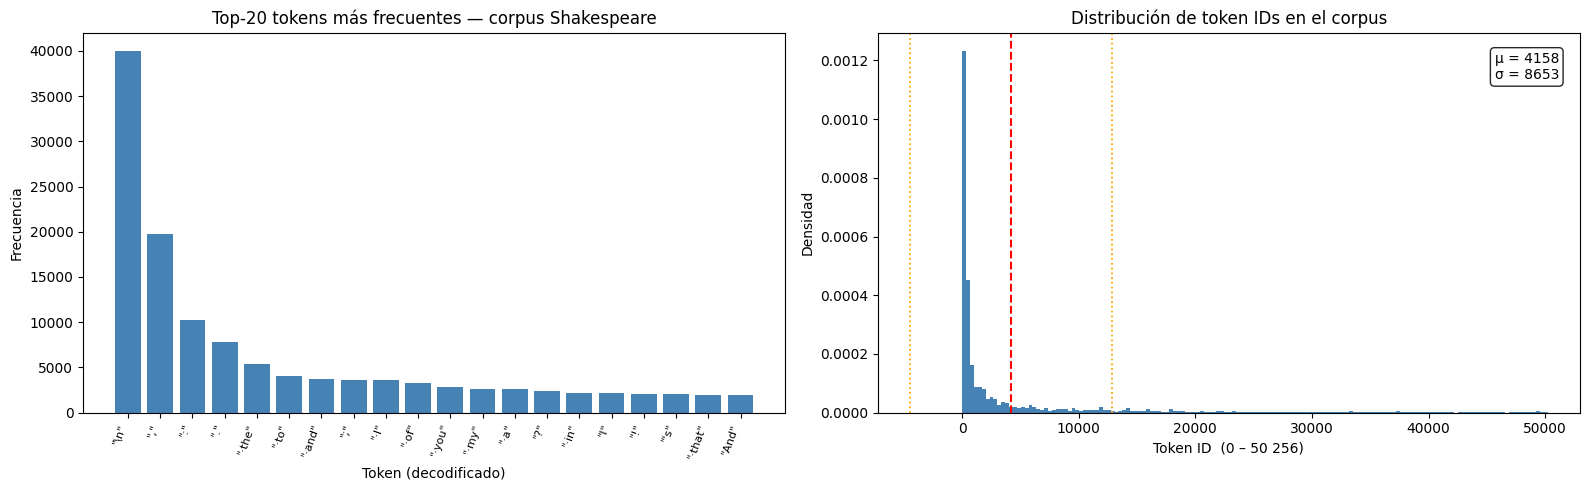

In [13]:
corpus_counter = Counter(encoded_corpus)
corpus_arr     = np.array(encoded_corpus)

TOP_N = 20
top_tokens = corpus_counter.most_common(TOP_N)
labels = ['"' + decode([t]).replace('\n', '\\n').replace(' ', '·') + '"' for t, _ in top_tokens]
freqs  = [c for _, c in top_tokens]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].bar(range(TOP_N), freqs, color='steelblue', edgecolor='none')
axes[0].set_xticks(range(TOP_N))
axes[0].set_xticklabels(labels, rotation=70, ha='right', fontsize=8)
axes[0].set_xlabel('Token (decodificado)')
axes[0].set_ylabel('Frecuencia')
axes[0].set_title(f'Top-{TOP_N} tokens más frecuentes — corpus Shakespeare')

mu, sigma = corpus_arr.mean(), corpus_arr.std()
axes[1].hist(encoded_corpus, bins=150, color='steelblue', edgecolor='none', density=True)
axes[1].axvline(mu,       color='red',    linestyle='--', linewidth=1.5)
axes[1].axvline(mu+sigma, color='orange', linestyle=':', linewidth=1.3)
axes[1].axvline(mu-sigma, color='orange', linestyle=':', linewidth=1.3)
axes[1].text(0.97, 0.95, f'μ = {mu:.0f}\nσ = {sigma:.0f}',
             transform=axes[1].transAxes, ha='right', va='top', fontsize=10,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
axes[1].set_xlabel('Token ID  (0 – 50 256)')
axes[1].set_ylabel('Densidad')
axes[1].set_title('Distribución de token IDs en el corpus')

plt.tight_layout()
plt.show()


<a id='sec2'></a>
# 2. GPT desde cero

Implementación completa de una arquitectura GPT entrenada sobre el corpus de Shakespeare, usando el tokenizador BPE de GPT-2 (vocabulario de 50 257 tokens).

<a id='sec21'></a>
## 2.1 DataLoader

Itera el corpus en lotes de ventanas deslizantes de *block_size* tokens. La entrada *x* y el objetivo *y* son la misma secuencia desplazada un token.

In [ ]:
class DataLoader:
    def __init__(self, corpus, block_size):
        self.corpus = torch.tensor(corpus, dtype=torch.long)
        self.block_size = block_size
        self.examples_index = list(range(0, len(corpus) - block_size, block_size))
        self.order = np.random.permutation(self.examples_index)
        self.curr_pos = 0
        self.stride = 0

    def get_batch(self, batch_size):
        batch_examples = self.order[self.curr_pos : self.curr_pos + batch_size]
        self.curr_pos += len(batch_examples)

        # Cuando se agota el corpus, reiniciar con distinto stride
        if len(batch_examples) < batch_size:
            self.curr_pos = 0
            self.stride = (self.stride + 1) % self.block_size
            self.examples_index = list(range(self.stride, len(self.corpus) - self.block_size, self.block_size))
            self.order = np.random.permutation(self.examples_index)
            if len(batch_examples) == 0:
                batch_examples = self.order[self.curr_pos : self.curr_pos + batch_size]
                self.curr_pos += len(batch_examples)

        x = torch.stack([self.corpus[i : i + self.block_size]         for i in batch_examples])
        y = torch.stack([self.corpus[i + 1 : i + 1 + self.block_size] for i in batch_examples])
        
        return x, y

<a id='sec22'></a>
## 2.2 Arquitectura

Transformer decoder-only: embeddings de token + posición, *blocks_num* bloques con multi-head self-attention causal y feed-forward, y una cabeza lineal de predicción.

In [ ]:
class SelfAttention(nn.Module):
    def __init__(self, embed_dim, head_dim, block_size):
        super().__init__()
        self.head_dim = head_dim
        self.Wq = nn.Linear(embed_dim, head_dim, bias=False)
        self.Wk = nn.Linear(embed_dim, head_dim, bias=False)
        self.Wv = nn.Linear(embed_dim, head_dim, bias=False)
        self.register_buffer('mask', torch.tril(torch.ones(block_size, block_size)))

    def forward(self, x):
        N, T, D = x.shape
        Q, K, V = self.Wq(x), self.Wk(x), self.Wv(x)
        att = Q @ K.transpose(-1, -2) * self.head_dim ** -0.5
        att = att.masked_fill(self.mask[:T, :T] == 0, float('-inf'))
        return F.softmax(att, dim=-1) @ V


class MultiHeadAttention(nn.Module):
    def __init__(self, heads_num, embed_dim, head_dim, block_size):
        super().__init__()
        self.heads = nn.ModuleList([
            SelfAttention(embed_dim, head_dim // heads_num, block_size)
            for _ in range(heads_num)
        ])
        self.dense = nn.Linear(head_dim, head_dim, bias=False)

    def forward(self, x):
        return self.dense(torch.cat([h(x) for h in self.heads], dim=-1))


class FeedForward(nn.Module):
    def __init__(self, in_dim, hidden_dim, out_dim):
        super().__init__()
        self.dense1 = nn.Linear(in_dim, hidden_dim)
        self.dense2 = nn.Linear(hidden_dim, out_dim)

    def forward(self, x):
        return self.dense2(F.relu(self.dense1(x)))


class Block(nn.Module):
    def __init__(self, heads_num, model_dim, block_size):
        super().__init__()
        self.attention = MultiHeadAttention(heads_num, model_dim, model_dim, block_size)
        self.ln1   = nn.LayerNorm(model_dim)
        self.ffd   = FeedForward(model_dim, model_dim * 4, model_dim)
        self.ln2   = nn.LayerNorm(model_dim)
        self.drop1 = nn.Dropout(0.1)
        self.drop2 = nn.Dropout(0.1)

    def forward(self, x):
        x = self.ln1(x + self.drop1(self.attention(x)))
        x = self.ln2(x + self.drop2(self.ffd(x)))
        return x


class GPT(nn.Module):
    def __init__(self, vocab_size, model_dim, block_size, blocks_num, heads_num):
        super().__init__()
        self.E      = nn.Embedding(vocab_size, model_dim)
        self.posE   = nn.Embedding(block_size, model_dim)
        self.ln1    = nn.LayerNorm(model_dim)
        self.drop   = nn.Dropout(0.1)
        self.blocks = nn.Sequential(*[
            Block(heads_num, model_dim, block_size) for _ in range(blocks_num)
        ])
        self.head = nn.Linear(model_dim, vocab_size, bias=False)

    def forward(self, x):
        positions = torch.arange(x.shape[1], device=x.device)
        emb = self.drop(self.ln1(self.E(x) + self.posE(positions)))
        return self.head(self.blocks(emb))


torch.manual_seed(SEED)
model = GPT(vocab_size, model_dim, block_size, blocks_num, heads_num).to(device)
print(f'Parámetros del modelo : {sum(p.numel() for p in model.parameters()):,}')

Parámetros del modelo : 64,098,304


<a id='sec23'></a>
## 2.3 Diagrama

Flujo de datos a través de la arquitectura GPT implementada (parámetros del experimento: *model_dim*=512, *block_size*=64, *heads_num*=8, *blocks_num*=4):

```
Secuencia de entrada  [batch, block_size=64]
         │
         ├─ Token Embedding       vocab_size=50 257 → 512
         └─ Positional Embedding  block_size=64     → 512
                    ↓  (suma)
             LayerNorm + Dropout(0.1)
                    ↓
    ┌───────────────────────────────────────┐
    │  Bloque Transformer  ×4               │
    │                                       │
    │  x ──→ LayerNorm                      │
    │           └─→ MultiHeadAttention      │
    │                 8 cabezas × 64 dim    │
    │                 máscara causal ▽      │
    │           └─→ Dropout(0.1)            │
    │  x = x + attn_out   (residual)        │
    │                                       │
    │  x ──→ LayerNorm                      │
    │           └─→ FeedForward             │
    │                 512 → 2 048 → 512     │
    │                 activación ReLU       │
    │           └─→ Dropout(0.1)            │
    │  x = x + ffn_out    (residual)        │
    └───────────────────────────────────────┘
                    ↓
           Linear  512 → 50 257
                    ↓
    Logits  [batch, block_size, vocab_size]
      ├─ Entrenamiento → CrossEntropyLoss
      └─ Generación    → Softmax + nucleus sampling (top-p)
```

<a id='sec24'></a>
## 2.4 Entrenamiento

Optimizador Adam con weight decay. Se evalúa la pérdida en train y validación cada época. Al finalizar se guarda el checkpoint.

In [16]:
@torch.no_grad()
def estimate_loss(model, train_eval, val_eval, eval_iters=10):
    model.eval()
    results = {}
    for name, loader in [('train', train_eval), ('val', val_eval)]:
        losses = []
        for _ in range(eval_iters):
            x, y = loader.get_batch(batch_size)
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))
            losses.append(loss.item())
        results[name] = sum(losses) / eval_iters
    model.train()
    return results['train'], results['val']


def training_loop(model, lr, max_steps, data_loader, train_eval, val_eval,
                  weight_decay=0.0, steps_per_log=100):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    train_losses, val_losses = [], []

    model.train()
    print(f'Entrenando por {max_steps} pasos...')
    for step in range(max_steps):
        x, y = data_loader.get_batch(batch_size)
        x, y = x.to(device), y.to(device)
        logits = model(x)
        loss = F.cross_entropy(logits.view(-1, vocab_size), y.view(-1))

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (step + 1) % steps_per_log == 0 or step == 0 or step == max_steps - 1:
            tl, vl = estimate_loss(model, train_eval, val_eval)
            print(f'Step {step+1:5d} | train loss: {tl:.4f} | val loss: {vl:.4f}')
            train_losses.append(tl)
            val_losses.append(vl)

    return train_losses, val_losses

Se realiza la inicialización de los DataLoaders para entrenamiento y validación, y se verifica si existe un checkpoint previo para cargar el modelo y las métricas. Si no se encuentra el checkpoint, se inicia el proceso de entrenamiento desde cero.

In [ ]:
np.random.seed(SEED)
train_data = DataLoader(train_corpus, block_size)
val_data   = DataLoader(val_corpus,   block_size)

steps_per_epoch = len(train_data.examples_index) // batch_size
print(f'Pasos por época: {steps_per_epoch}')

short_path          = "/".join(CKPT_SCRATCH.split("/")[-2:])
metrics_scratch_path = os.path.join(os.path.dirname(CKPT_SCRATCH), "metrics_scratch.json")
metrics_short_path  = "/".join(metrics_scratch_path.split("/")[-2:])

if os.path.exists(CKPT_SCRATCH):
    print(f"\n[INFO] Checkpoint encontrado. Cargando modelo desde: {short_path}")
    model.load_state_dict(torch.load(CKPT_SCRATCH, map_location=device))

    if os.path.exists(metrics_scratch_path):
        with open(metrics_scratch_path, 'r') as f:
            saved = json.load(f)
        nll_scratch  = saved["nll_scratch"]
        train_losses = saved["train_losses"]
        val_losses   = saved["val_losses"]
        print(f"[INFO] Métricas y curvas cargadas (Val loss: {nll_scratch:.4f})")
    else:
        print("[INFO] Calculando métricas faltantes...")
        _, nll_scratch = estimate_loss(
            model,
            DataLoader(train_corpus, block_size),
            DataLoader(val_corpus, block_size),
        )
        train_losses, val_losses = [], []
        with open(metrics_scratch_path, 'w') as f:
            json.dump({"nll_scratch": nll_scratch,
                       "train_losses": train_losses,
                       "val_losses": val_losses}, f)
        print(f"[INFO] Métricas guardadas en {metrics_short_path}")

else:
    train_losses, val_losses = training_loop(
        model,
        lr=3e-4,
        max_steps=20 * steps_per_epoch,
        data_loader=train_data,
        train_eval=DataLoader(train_corpus, block_size),
        val_eval=DataLoader(val_corpus,   block_size),
        weight_decay=1e-4,
        steps_per_log=steps_per_epoch,
    )

    _, nll_scratch = estimate_loss(
        model,
        DataLoader(train_corpus, block_size),
        DataLoader(val_corpus,   block_size),
    )
    print(f'Val loss   : {nll_scratch:.4f}')
    print(f'Perplexity : {math.exp(nll_scratch):.2f}')

    os.makedirs(os.path.dirname(CKPT_SCRATCH), exist_ok=True)
    torch.save(model.state_dict(), CKPT_SCRATCH)
    print(f'Checkpoint guardado : {short_path}')

    with open(metrics_scratch_path, 'w') as f:
        json.dump({"nll_scratch": nll_scratch,
                   "train_losses": train_losses,
                   "val_losses": val_losses}, f)
    print(f'Métricas guardadas  : {metrics_short_path}')


Pasos por época: 74

[INFO] Checkpoint encontrado. Cargando modelo desde: checkpoints/gpt_scratch.pt
[INFO] Métricas y curvas cargadas (Val loss: 4.6013)


<a id='sec25'></a>
## 2.5 Curvas de pérdida

La brecha entre train y val loss refleja overfitting esperado dado el corpus pequeño (~338 k tokens). Se aplicó *Dropout(0.1)* y weight decay como regularización.

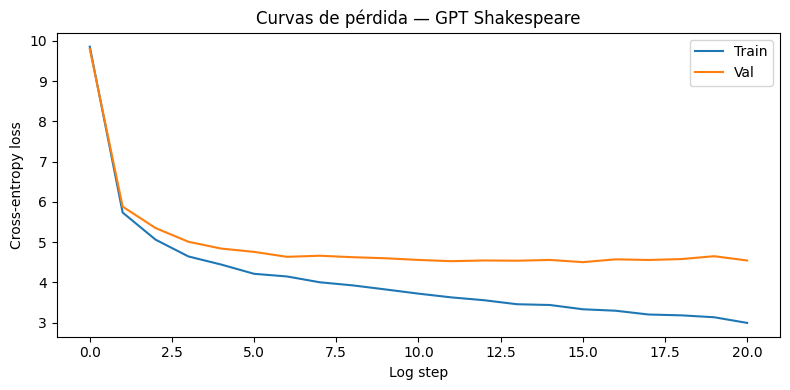

In [18]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label='Train')
plt.plot(val_losses,   label='Val')
plt.xlabel('Log step')
plt.ylabel('Cross-entropy loss')
plt.title('Curvas de pérdida — GPT Shakespeare')
plt.legend()
plt.tight_layout()
plt.show()

<a id='sec3'></a>
# 3. GPT-2 Finetuning

Carga del modelo GPT-2 preentrenado (124 M parámetros) y ajuste sobre el corpus de Shakespeare usando la librería *transformers* de Hugging Face.

<a id='sec31'></a>
## 3.1 Setup y preparación de datos

Se reutiliza *corpus_text* cargado en [Sección 1](#sec1). El texto se tokeniza con el tokenizador propio de GPT-2, se agrupa en bloques de *FT_BLOCK_SIZE=128* y se divide en train/val.

<a id='sec32'></a>
## 3.2 Entrenamiento

Se usa el *Trainer* de Hugging Face con learning rate bajo (2e-5) para no sobreescribir el conocimiento preaprendido. Al finalizar se guarda el checkpoint.

Se realiza la inicialización de los DataLoaders para entrenamiento y validación, y se verifica si existe un checkpoint previo para cargar el modelo y las métricas. Si no se encuentra el checkpoint, se inicia el proceso de entrenamiento desde cero.


In [ ]:
MODEL_NAME    = "gpt2"
FT_BLOCK_SIZE = 128
TRAIN_RATIO   = 0.9

# ── Tokenizer y modelo 
ft_tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
if ft_tokenizer.pad_token is None:
    ft_tokenizer.pad_token = ft_tokenizer.eos_token

ft_model = AutoModelForCausalLM.from_pretrained(MODEL_NAME).to(device)
ft_model.config.pad_token_id = ft_tokenizer.pad_token_id
print(f'Parámetros GPT-2 : {sum(p.numel() for p in ft_model.parameters()):,}')

# ── Dataset 
raw_dataset = Dataset.from_dict({"text": [corpus_text]})

def tokenize_function(examples):
    return ft_tokenizer(examples["text"])

def group_texts(examples):
    concatenated = {k: sum(examples[k], []) for k in examples.keys()}
    total = (len(concatenated["input_ids"]) // FT_BLOCK_SIZE) * FT_BLOCK_SIZE
    result = {
        k: [t[i:i + FT_BLOCK_SIZE] for i in range(0, total, FT_BLOCK_SIZE)]
        for k, t in concatenated.items()
    }
    result["labels"] = result["input_ids"].copy()
    return result

lm_dataset    = raw_dataset.map(tokenize_function, batched=True, remove_columns=["text"])
lm_dataset    = lm_dataset.map(group_texts, batched=True)
split_dataset = lm_dataset.train_test_split(test_size=1 - TRAIN_RATIO, seed=SEED)
train_dataset = split_dataset["train"]
eval_dataset  = split_dataset["test"]
print(f'Ejemplos — train : {len(train_dataset):,}  |  val : {len(eval_dataset):,}')

# ── Trainer
data_collator = DataCollatorForLanguageModeling(tokenizer=ft_tokenizer, mlm=False)

training_args = TrainingArguments(
    output_dir=f'{DRIVE_BASE}/checkpoints/gpt2_ft_trainer',
    num_train_epochs=10,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    gradient_accumulation_steps=4,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_steps=120,
    lr_scheduler_type="cosine",
    eval_strategy="epoch",
    save_strategy="no",
    logging_strategy="steps",
    logging_steps=20,
    fp16=torch.cuda.is_available(),
    report_to="none",
    seed=SEED,
)

trainer = Trainer(
    model=ft_model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    data_collator=data_collator,
)

short_path = "/".join(CKPT_FT.split("/")[-2:])
metrics_ft_path = os.path.join(os.path.dirname(CKPT_FT), "metrics_ft.json")
metrics_short_path = "/".join(metrics_ft_path.split("/")[-2:])

if os.path.exists(CKPT_FT):
    print(f"\n[INFO] Checkpoint encontrado. Cargando GPT-2 Finetuned desde: {short_path}")
    ft_model.load_state_dict(torch.load(CKPT_FT, map_location=device))

    if os.path.exists(metrics_ft_path):
        with open(metrics_ft_path, 'r') as f:
            saved = json.load(f)
        nll_ft = saved["nll_ft"]
        trainer.state.log_history = saved["log_history"]
        print(f"[INFO] Métricas y curvas cargadas (Eval loss: {nll_ft:.4f})")
    else:
        print("[INFO] Calculando métricas faltantes...")
        nll_ft = trainer.evaluate()["eval_loss"]
        with open(metrics_ft_path, 'w') as f:
            json.dump({"nll_ft": nll_ft,
                       "log_history": trainer.state.log_history}, f)
        print(f"[INFO] Métricas guardadas en {metrics_short_path}")

else:
    trainer.train()

    nll_ft = trainer.evaluate()["eval_loss"]
    print(f'Eval loss  : {nll_ft:.4f}')
    print(f'Perplexity : {math.exp(nll_ft):.2f}')

    os.makedirs(os.path.dirname(CKPT_FT), exist_ok=True)
    torch.save(ft_model.state_dict(), CKPT_FT)
    print(f'Checkpoint guardado : {short_path}')

    with open(metrics_ft_path, 'w') as f:
        json.dump({"nll_ft": nll_ft,
                   "log_history": trainer.state.log_history}, f)
    print(f'Métricas guardadas  : {metrics_short_path}')


Parámetros GPT-2 : 124,439,808
Ejemplos — train : 2,376  |  val : 264

[INFO] Checkpoint encontrado. Cargando GPT-2 Finetuned desde: checkpoints/gpt2_ft.pt
[INFO] Métricas y curvas cargadas (Eval loss: 3.4257)


<a id='sec33'></a>
## 3.3 Curvas de pérdida

El el modelo con finetuning converge a una pérdida de validación menor gracias al preentrenamiento masivo de GPT-2 (40 GB de texto inglés general).

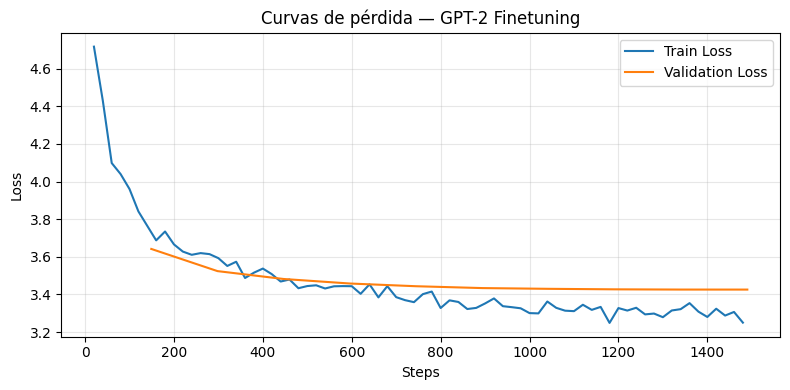

In [20]:
log_history = trainer.state.log_history

train_loss_ft, eval_loss_ft = [], []
steps_train_ft, steps_eval_ft = [], []

for log in log_history:
    if "loss" in log and "eval_loss" not in log:
        train_loss_ft.append(log["loss"])
        steps_train_ft.append(log["step"])
    if "eval_loss" in log:
        eval_loss_ft.append(log["eval_loss"])
        steps_eval_ft.append(log["step"])

plt.figure(figsize=(8, 4))
plt.plot(steps_train_ft, train_loss_ft, label="Train Loss")
plt.plot(steps_eval_ft,  eval_loss_ft,  label="Validation Loss")
plt.xlabel("Steps")
plt.ylabel("Loss")
plt.title("Curvas de pérdida — GPT-2 Finetuning")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

<a id='sec4'></a>
# 4. Generación

Se definen dos funciones de generación adaptadas a cada arquitectura: 

- ***generate_scratch***: generación token a token para el GPT entrenado desde cero. Usa *nucleus sampling* (top-p): en cada paso muestrea del conjunto mínimo de tokens cuya probabilidad acumulada supera *top_p*.
- ***generate_hf***: generación para modelos HuggingFace con *model.generate()*.

**Nota:** Los parámetros de decodificación de *generate_hf* se establecieron de forma heurística. Se observó que valores altos de *repetition_penalty* eliminaban el formato de guion teatral (saltos de línea, nombres de personaje repetidos), mientras que valores bajos permitían loops semánticos largos. Se eligieron *temperature=0.6*, *repetition_penalty=1.05* y *no_repeat_ngram_size=6* como balance entre diversidad léxica y coherencia del formato.

Además, se realiza una generación de texto con el modelo GPT-2 sin hacerle *finetuning* con el fin de comparar la salida de este con la del modelo con finetuning y ver si hay alguna diferencia real.

In [ ]:
PROMPTS = [
    (
        "KING EDWARD IV:\nMy lord, what news?\n\n"
        "QUEEN ELIZABETH:\nThe people murmur at your grace.\n\n"
        "KING EDWARD IV:\n"
    ),
    (
        "HAMLET:\nTo be, or not to be, that is the question.\n\n"
        "KING:\nAnd what answer dost thou give?\n\n"
        "HAMLET:\n"
    ),
    (
        "All:\nSpeak, speak.\n\n"
        "First Citizen:\nBefore we proceed any further, hear me speak.\n\n"
        "All:\n"
    ),
]

# Función de generación de texto para el modelo entrenado desde cero
@torch.no_grad()
def generate_scratch(model, prompt, max_tokens=300, temperature=0.8, top_p=0.9):
    model.eval()
    ids = torch.tensor([encode(prompt)], dtype=torch.long).to(device)
    for _ in range(max_tokens):
        logits = model(ids[:, -block_size:])[:, -1, :] / temperature
        probs = F.softmax(logits, dim=-1)
        sorted_p, sorted_i = torch.sort(probs, descending=True)
        cum_p = torch.cumsum(sorted_p, dim=-1)
        mask = (cum_p - sorted_p) < top_p
        filtered = sorted_p * mask
        if filtered.sum() == 0:
            filtered = probs
        filtered = filtered / filtered.sum()
        idx = torch.multinomial(filtered, 1)
        next_tok = sorted_i.gather(-1, idx)
        ids = torch.cat((ids, next_tok), dim=1)
    return decode(ids[0].tolist())

# Función de generación de texto para el modelo finetuneado
def generate_hf(model, tokenizer, prompt, max_new_tokens=300,
                temperature=0.6, top_p=0.9, top_k=40,
                repetition_penalty=1.05, no_repeat_ngram_size=6):
    input_ids     = torch.tensor([tokenizer.encode(prompt)], dtype=torch.long).to(device)
    attention_mask = torch.ones_like(input_ids)
    with torch.no_grad(), warnings.catch_warnings():
        warnings.simplefilter("ignore")
        out = model.generate(
            input_ids,
            attention_mask=attention_mask,
            max_new_tokens=max_new_tokens,
            do_sample=True,
            temperature=temperature,
            top_p=top_p,
            top_k=top_k,
            repetition_penalty=repetition_penalty,
            no_repeat_ngram_size=no_repeat_ngram_size,
            pad_token_id=tokenizer.eos_token_id,
        )
    return tokenizer.decode(out[0].tolist())


<a id='sec41'></a>
## 4.1 Generación con GPT scratch

Se generan 500 tokens a partir del primer prompt. Los tokens generados se guardan para el análisis comparativo de [Sección 5.3](#sec53).

Estos textos generados son utilizados para realizar el análisis comparativo, los 3 textos solicitados en la rúbrica se generan en la [Sección 8](#sec8).

In [22]:
gen_scratch_text = generate_scratch(model, PROMPTS[0], max_tokens=500, temperature=0.8, top_p=0.9)
gen_scratch_ids  = encode(gen_scratch_text)
print(gen_scratch_text)

KING EDWARD IV:
My lord, what news?

QUEEN ELIZABETH:
The people murmur at your grace.

KING EDWARD IV:
Why, so shall I be plain,
But at your former cause?

QUEEN MARGARET:
Ay, my noble lord, and my sovereign,
And now 'tis yours to be your grace.

GLOUCESTER:
Then let me stay, be gentle,
To be crowned, and then I'll give.

QUEEN MARGARET:
I mean, farewell:
Let me speak, and I'll swear with thee.

KING EDWARD IV:
Go, by Saint George, and be gone.

GLOUCESTER:
Why, madam, what wilt thou go?

LADY GREY:
No, no, I beseech you, not, but still the grace I cannot say.

GLOUCESTER:
I can read it with the coronation,
For for a prayer of small consequence, but I'll have you both.

KING EDWARD IV:
I mean, I will; I'll give you a wrong,
And pray you, father, take it well.

KING EDWARD IV:
It is: there is my name is no creature,
That I should do what Edward is mine.

GLOUCESTER:
And, gracious lord, you should here do it.

CLARENCE:
I'll have a happy time of mine.

GLOUCESTER:
I'll lay at any thing,

<a id='sec42'></a>
## 4.2 Generación con GPT-2 finetuned

Mismo prompt. Se usa *generate_hf* con los parámetros heurísticos definidos en [Sección 4](#sec4).

Estos textos generados son utilizados para realizar el análisis comparativo, los 3 textos solicitados en la rúbrica se generan en la [Sección 8](#sec8).

In [23]:
gen_ft_text = generate_hf(ft_model, ft_tokenizer, PROMPTS[0], max_new_tokens=500)
gen_ft_ids  = ft_tokenizer.encode(gen_ft_text)
print(gen_ft_text)

KING EDWARD IV:
My lord, what news?

QUEEN ELIZABETH:
The people murmur at your grace.

KING EDWARD IV:
'Tis true; and I do hope they will hear it again in person.
And now you have done the duty of a king to me--
I am so much loved by all my subjects that there is no need
of any more ado about their needs! They are well pleased with themselves,
and seem contented for every word which comes from them.
But if this be an idle tale then let's see how we may get our way home.
We shall find some good men here who would like us both together.
It should not take long before one or two come along as friends.
Your son Edward deserves great thanks out of his brother Richard.
Now he hath gone away through France into England where none but himself sits.
For many years she has made him queen over these lands,
To keep her royal dignity alive while thyself reigns supreme.
She sends forth princes hither whom thou hast promised kingship.
They say God giveth peace unto thee alone; yet 'tis plain enough:

<a id='sec43'></a>
## 4.3 Generación con GPT-2 base (sin finetuning)

Se carga el modelo GPT-2 preentrenado sin ajustar. Sirve de línea base para aislar el efecto del finetuning sobre el estilo shakespeariano.

In [24]:
base_tokenizer = AutoTokenizer.from_pretrained("gpt2")
base_model     = AutoModelForCausalLM.from_pretrained("gpt2").to(device)
base_model.eval()
if base_tokenizer.pad_token is None:
    base_tokenizer.pad_token = base_tokenizer.eos_token
print(f'GPT-2 base : {sum(p.numel() for p in base_model.parameters()):,} parámetros')

GPT-2 base : 124,439,808 parámetros


In [29]:
gen_base_text = generate_hf(base_model, base_tokenizer, PROMPTS[0], max_new_tokens=500)
gen_base_ids  = base_tokenizer.encode(gen_base_text)
print(gen_base_text)

KING EDWARD IV:
My lord, what news?

QUEEN ELIZABETH:
The people murmur at your grace.

KING EDWARD IV:
 I am a man of the Lord!
 (Sighs) How dare you deny my love for thee?
- When he has said so to me; - when his heart is full of tears and fury.
(He turns round with an expression which says 'I will not forgive him,' but that it was just as if they had spoken.)
"You are such a fool!" cried Eliza. "Why should any one be offended by this?"
[A voice in her ear] You have been deceived indeed."
Earl's eyes went wide. He looked back down again before she could hear anything else. Then suddenly there came out from behind them another cry of agony. The old lady began to weep hysterically. She did not know whether or how much sorrowing would follow after having gone through all these things without seeing something like their face come together once more. But now we were on our way home into town, while Queen Elizabeth held up her hand to answer those who spoke ill of us. We saw no other signs 

<a id='sec5'></a>
# 5. Evaluación

<a id='sec51'></a>
## 5.1 Comparación de entrenamiento

Tabla resumen con las métricas finales de ambos modelos sobre el conjunto de validación.

In [ ]:
params_scratch = sum(p.numel() for p in model.parameters())
params_ft = sum(p.numel() for p in ft_model.parameters())

print('=' * 55)
print(f'{"Métrica":<25} {"Scratch":>12} {"Finetuning":>14}')
print('=' * 55)
print(f'{"Parámetros":<25} {params_scratch:>12,} {params_ft:>14,}')
print(f'{"Val loss":<25} {nll_scratch:>12.4f} {nll_ft:>14.4f}')
print(f'{"Log-likelihood":<25} {-nll_scratch:>12.4f} {-nll_ft:>14.4f}')
print(f'{"Perplexity":<25} {math.exp(nll_scratch):>12.2f} {math.exp(nll_ft):>14.2f}')
print('=' * 55)

Métrica                        Scratch     Finetuning
Parámetros                  64,098,304    124,439,808
Val loss (NLL/token)            4.6013         3.4257
Log-likelihood/token           -4.6013        -3.4257
Perplexity                       99.61          30.74


<a id='sec52'></a>
## 5.2 Perplexity comparativa

La perplexity indica entre cuántas opciones duda el modelo en promedio al predecir cada token. Menor es mejor.

In [31]:
df_eval = pd.DataFrame({
    'Modelo':       ['GPT scratch', 'GPT-2 Finetuned'],
    'Parámetros':   [sum(p.numel() for p in model.parameters()),
                     sum(p.numel() for p in ft_model.parameters())],
    'Val loss':     [round(nll_scratch, 4), round(nll_ft, 4)],
    'Perplexity':   [round(math.exp(nll_scratch), 2), round(math.exp(nll_ft), 2)],
}).set_index('Modelo')

df_eval.style.format({'Parámetros': '{:,}', 'Val loss': '{:.4f}', 'Perplexity': '{:.2f}'})


,Parámetros,Val loss,Perplexity
Modelo,,,
GPT scratch,"64,098,304",4.6013,99.61
GPT-2 Finetuned,"124,439,808",3.4257,30.74


<a id='sec53'></a>
## 5.3 Comparación de distribuciones

Se compara la distribución de token IDs y los tokens más frecuentes entre el corpus original y los textos generados por cada modelo (500 tokens cada uno, del [Sección 4](#sec4)).

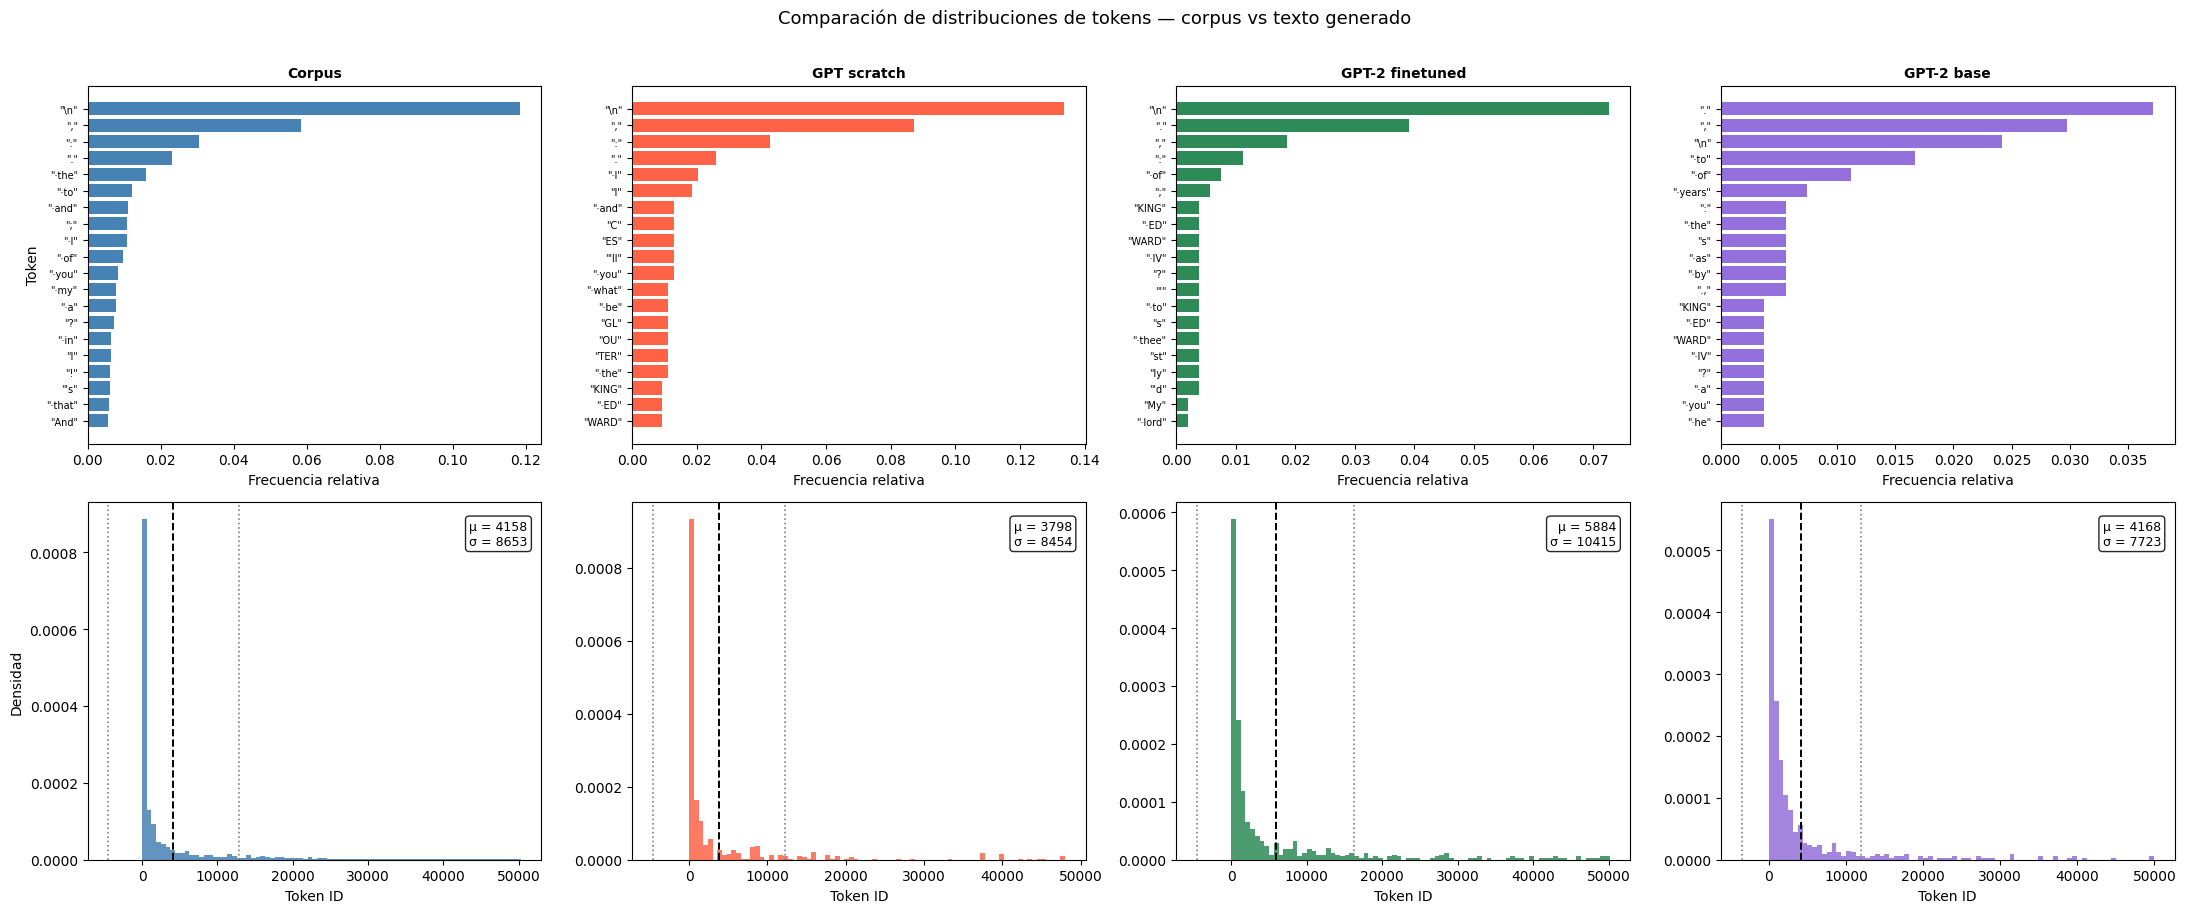

In [32]:
sources = {
    'Corpus':          (encoded_corpus,  'steelblue'),
    'GPT scratch':     (gen_scratch_ids, 'tomato'),
    'GPT-2 finetuned': (gen_ft_ids,      'seagreen'),
    'GPT-2 base':      (gen_base_ids,    'mediumpurple'),
}

TOP_N = 20
fig, axes = plt.subplots(2, 4, figsize=(22, 9))

for col, (name, (ids, color)) in enumerate(sources.items()):
    arr     = np.array(ids)
    counter = Counter(ids)

    top   = counter.most_common(TOP_N)
    tlabs = ['"' + decode([t]).replace('\n', '\\n').replace(' ', '·') + '"' for t, _ in top]
    tfreq = [c / len(ids) for _, c in top]
    axes[0, col].barh(range(TOP_N), tfreq[::-1], color=color, edgecolor='none')
    axes[0, col].set_yticks(range(TOP_N))
    axes[0, col].set_yticklabels(tlabs[::-1], fontsize=7)
    axes[0, col].set_xlabel('Frecuencia relativa')
    axes[0, col].set_title(name, fontsize=10, fontweight='bold')
    if col == 0: axes[0, col].set_ylabel('Token')

    mu, sigma = arr.mean(), arr.std()
    axes[1, col].hist(ids, bins=80, color=color, edgecolor='none', density=True, alpha=0.85)
    axes[1, col].axvline(mu,       color='black', linestyle='--', linewidth=1.4)
    axes[1, col].axvline(mu+sigma, color='gray',  linestyle=':',  linewidth=1.2)
    axes[1, col].axvline(mu-sigma, color='gray',  linestyle=':',  linewidth=1.2)
    axes[1, col].text(0.97, 0.95, f'μ = {mu:.0f}\nσ = {sigma:.0f}',
                      transform=axes[1, col].transAxes, ha='right', va='top',
                      fontsize=9, bbox=dict(boxstyle='round', facecolor='white', alpha=0.85))
    axes[1, col].set_xlabel('Token ID')
    if col == 0: axes[1, col].set_ylabel('Densidad')

plt.suptitle('Comparación de distribuciones de tokens — corpus vs texto generado',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()


<a id='sec54'></a>
## 5.4 Log-likelihood y distribución de longitudes de longitudes de línea de diálogo

Mide qué tan probable le parece a cada modelo un texto dado. Se compara el texto real de validación con el texto que cada modelo generó.

                         Scratch LL      FT LL    Base LL
────────────────────────────────────────────────────────
Texto real (val)            -3.7138    -2.3664    -3.4851
GPT scratch gen.            -1.8779    -2.2314    -3.2441
GPT-2 FT gen.               -2.7250    -2.8242    -3.8020
GPT-2 base gen.             -4.0238    -3.5440    -3.2284


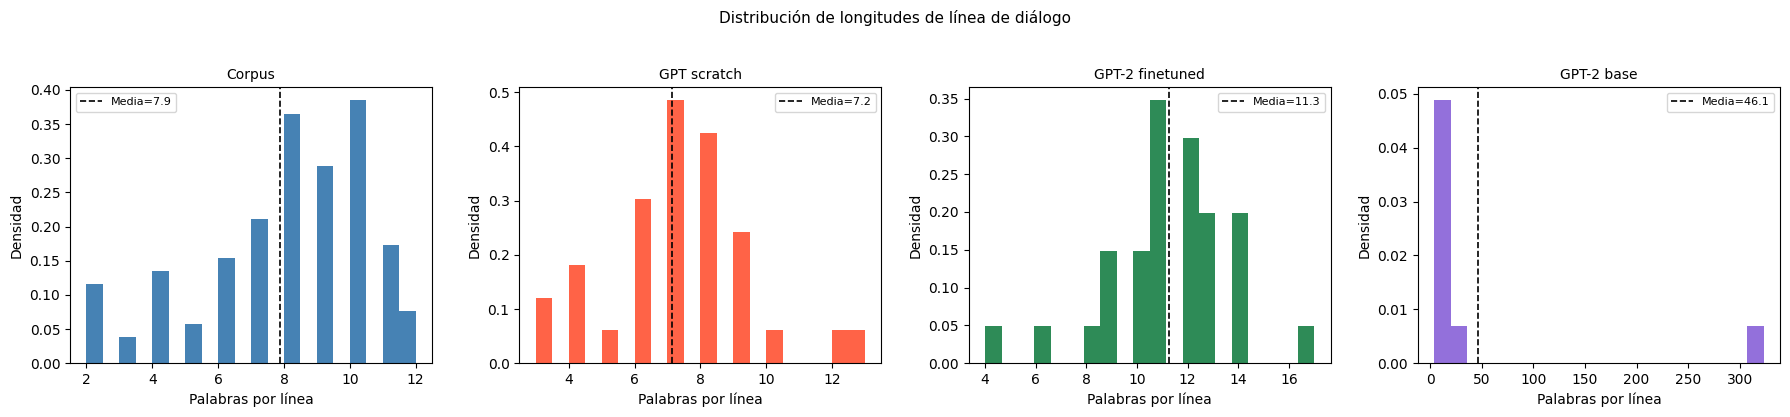

In [33]:
@torch.no_grad()
def avg_ll_hf(model, tokenizer, text, max_len=256):
    """Log-likelihood promedio bajo un modelo HuggingFace."""
    model.eval()
    ids = tokenizer(text, return_tensors='pt', truncation=True,
                    max_length=max_len).input_ids.to(device)
    x, y = ids[:, :-1], ids[:, 1:]
    lp = F.log_softmax(model(x).logits, dim=-1)
    return lp[0, range(y.shape[1]), y[0]].mean().item()

@torch.no_grad()
def avg_ll_scratch(model, text):
    """Log-likelihood promedio bajo el modelo scratch (ventana = block_size)."""
    model.eval()
    ids = torch.tensor([encode(text)], dtype=torch.long).to(device)
    ids = ids[:, :block_size + 1]
    x, y = ids[:, :-1], ids[:, 1:]
    lp = F.log_softmax(model(x), dim=-1)
    return lp[0, range(y.shape[1]), y[0]].mean().item()

val_sample = decode(val_corpus[:300])

rows = [
    ("Texto real (val)",  val_sample,       val_sample,       val_sample),
    ("GPT scratch gen.",  gen_scratch_text, gen_scratch_text, gen_scratch_text),
    ("GPT-2 FT gen.",     gen_ft_text,      gen_ft_text,      gen_ft_text),
    ("GPT-2 base gen.",   gen_base_text,    gen_base_text,    gen_base_text),
]

print(f'{"":22} {"Scratch LL":>12} {"FT LL":>10} {"Base LL":>10}')
print('─' * 56)
for label, t_sc, t_ft, t_base in rows:
    ll_sc   = avg_ll_scratch(model,      t_sc)
    ll_ft   = avg_ll_hf(ft_model,   ft_tokenizer,   t_ft)
    ll_base = avg_ll_hf(base_model, base_tokenizer, t_base)
    print(f'{label:<22} {ll_sc:>12.4f} {ll_ft:>10.4f} {ll_base:>10.4f}')

def line_lengths(text):
    lines = [l.strip() for l in text.split('\n')
             if l.strip() and not l.strip().endswith(':')]
    return [len(l.split()) for l in lines if len(l.split()) > 0]

sources_text = {
    'Corpus':         corpus_text[:5000],
    'GPT scratch':    gen_scratch_text,
    'GPT-2 finetuned': gen_ft_text,
    'GPT-2 base':     gen_base_text,
}
colors_4 = ['steelblue', 'tomato', 'seagreen', 'mediumpurple']

fig, axes = plt.subplots(1, 4, figsize=(18, 4), sharey=False)
for ax, (label, text), color in zip(axes, sources_text.items(), colors_4):
    lengths = line_lengths(text)
    if lengths:
        ax.hist(lengths, bins=20, color=color, edgecolor='none', density=True)
        ax.axvline(sum(lengths)/len(lengths), color='black', linestyle='--',
                   linewidth=1.2, label=f'Media={sum(lengths)/len(lengths):.1f}')
        ax.legend(fontsize=8)
    ax.set_xlabel('Palabras por línea')
    ax.set_ylabel('Densidad')
    ax.set_title(label, fontsize=10)

plt.suptitle('Distribución de longitudes de línea de diálogo',
             fontsize=11, y=1.03)
plt.tight_layout()
plt.show()


Los resultados vistos anteriormente son resultados obtenidos a partir del texto generado por los 3 modelos (GPT scratch, GPT-2 finetunned y GPT2-base). Dado que son modelo probabiliticos, los resultados varian cada ves que se generan nuevos textos para la evaluación.

<a id='sec55'></a>
## 5.5 Distinct-N

*Distinct-N* mide la proporción de $N$-gramas únicos sobre el total de $N$-gramas generados:

$$\text{Distinct-}N = \frac{\text{Cantidad de } N\text{-gramas únicos}}{\text{Cantidad total de } N\text{-gramas generados}}$$

Se reportan Distinct-1 (unigramas) y Distinct-2 (bigramas). Valores bajos indican texto repetitivo; valores muy cercanos a 1 pueden reflejar diversidad artificial producto de penalizaciones agresivas en el decoding, en lugar de riqueza léxica genuina.

In [34]:
def calcular_distinct_n(texto, n):
    texto_limpio = re.sub(r'[^\w\s]', '', texto.lower())
    palabras = texto_limpio.split()
    if len(palabras) < n:
        return 0.0
    ngrams = []
    for i in range(len(palabras) - n + 1):
        ngram = tuple(palabras[i:i+n])
        ngrams.append(ngram)
    ngrams_unicos = set(ngrams)
    return len(ngrams_unicos) / len(ngrams)

In [35]:
# Se generan 500 tokens para tener una buena muestra
seed_eval = "HAMLET:\nTo be or not to be"
gen_scratch = generate_scratch(model, seed_eval, max_tokens=500, temperature=0.8, top_p=0.9)
gen_ft = generate_hf(ft_model, ft_tokenizer, seed_eval, max_new_tokens=500, temperature=0.8, top_p=0.9)

print(f"Scratch (Distinct-1): {calcular_distinct_n(gen_scratch, 1):.4f} | (Distinct-2): {calcular_distinct_n(gen_scratch, 2):.4f}")
print(f"GPT-2 FT (Distinct-1): {calcular_distinct_n(gen_ft, 1):.4f} | (Distinct-2): {calcular_distinct_n(gen_ft, 2):.4f}")

Scratch (Distinct-1): 0.5159 | (Distinct-2): 0.9078
GPT-2 FT (Distinct-1): 0.9073 | (Distinct-2): 0.9975


### Interpretación (Distinct-N)

El modelo Scratch presenta un Distinct-1 de 0.5159 y un Distinct-2 de 0.9073, lo que refleja un balance razonable: cierta repetición de palabras funcionales (artículos, preposiciones) convive con variedad en las combinaciones de pares. GPT-2 Fine-tuned, en cambio, obtiene valores de 0.9078 y 0.9975, anormalmente altos para texto natural. La causa probable es la penalización por repetición configurada durante la generación, que forzó al modelo a seleccionar tokens cada vez menos probables, sacrificando coherencia a cambio de novedad artificial.

<a id='sec56'></a>
## 5.6 CKA (Similitud de Representaciones Internas)

*CKA* (*Centered Kernel Alignment*) compara las representaciones internas de dos redes neuronales ante una misma entrada. Su valor va de 0 (representaciones sin relación) a 1 (representaciones matemáticamente idénticas). A diferencia de una comparación directa de pesos, CKA es invariante al tamaño de las capas, lo que permite contrastar modelos con dimensiones distintas (512 vs. 768).

Se comparan las activaciones de la última capa oculta de cada modelo sobre el mismo conjunto de secuencias de validación.

In [36]:
def linear_cka(activaciones_X, activaciones_Y):

    X_centered = activaciones_X - activaciones_X.mean(dim=0, keepdim=True)
    Y_centered = activaciones_Y - activaciones_Y.mean(dim=0, keepdim=True)


    dot_product = torch.matmul(X_centered.t(), Y_centered)
    numerador = torch.norm(dot_product, p='fro') ** 2

    norm_X = torch.norm(torch.matmul(X_centered.t(), X_centered), p='fro')
    norm_Y = torch.norm(torch.matmul(Y_centered.t(), Y_centered), p='fro')
    denominador = norm_X * norm_Y

    return (numerador / denominador).item()

In [37]:
activations = {}
def capture_activations(layer_name):
    def hook(module, input, output):

        if isinstance(output, tuple):
            activations[layer_name] = output[0].detach()
        else:
            activations[layer_name] = output.detach()
    return hook

In [38]:
hook_scratch = model.blocks[-1].register_forward_hook(capture_activations("scratch_top"))
hook_ft = ft_model.transformer.h[-1].register_forward_hook(capture_activations("ft_top"))

In [39]:
# Se hace un forward pass con el mismo batch por ambos modelos
test_input_ids = torch.tensor([encode(seed_eval)], dtype=torch.long).to(device)

model.eval()
ft_model.eval()
with torch.no_grad():
    _ = model(test_input_ids)
    _ = ft_model(input_ids=test_input_ids)

hook_scratch.remove()
hook_ft.remove()

In [40]:
# CKA necesita matrices [batch * seq_len, hidden_dim]
act_scratch = activations["scratch_top"].view(-1, activations["scratch_top"].shape[-1])
act_ft = activations["ft_top"].view(-1, activations["ft_top"].shape[-1])

similitud_cka = linear_cka(act_scratch, act_ft)
print(f"Similitud CKA entre las últimas capas de ambos modelos: {similitud_cka:.4f}")

Similitud CKA entre las últimas capas de ambos modelos: 0.6467


### Interpretación (CKA)

El coeficiente obtenido al comparar las últimas capas ocultas de ambos modelos es $0.6467$. Este valor indica que, pese a las diferencias en tamaño y origen del preentrenamiento, los dos modelos desarrollaron representaciones parcialmente convergentes sobre el texto de Shakespeare. La brecha restante (~35 %) es coherente con que GPT-2 fue preentrenado en un corpus de propósito general de 40 GB, lo que imprime patrones léxicos y semánticos más amplios que los del modelo Scratch, entrenado exclusivamente sobre ~338 k tokens del corpus isabelino.

<a id='sec57'></a>
## 5.7 MAUVE (Divergencia de Distribuciones)

*MAUVE* evalúa qué tan parecida es la distribución del texto generado a la del texto de referencia. Un modelo externo (GPT-2 grande) convierte ambos textos en representaciones vectoriales y se calcula el área de superposición entre las distribuciones resultantes. El valor va de 0 a 1, donde 1 indica distribuciones estadísticamente indistinguibles.

Se compara el texto generado por cada modelo contra fragmentos del corpus de Shakespeare no vistos durante el entrenamiento.

In [ ]:
# Se toman 250 fragmentos del corpus de validación original como "textos humanos"
val_texts = []
chunk_size = 64
for i in range(250):
    # Se toman partes del val_corpus
    idx = i * chunk_size
    if idx + chunk_size < len(val_corpus):
        val_texts.append(decode(val_corpus[idx:idx+chunk_size]))

# Se generan fragmentos con los modelos
gen_texts_scratch = []
gen_texts_ft = []
print("Generando secuencias para computar MAUVE...")

for i in tqdm(range(250), desc="Generando ejemplos"):
    rand_idx = np.random.randint(0, len(val_corpus) - 10)

    # Se convierten los 5 tokens iniciales elegidos a texto.
    seed_mauve_str = decode(val_corpus[rand_idx:rand_idx+5])

    # Scratch
    # Se usa max_tokens tal como está en tu función generate_scratch (sin max_context)
    out_s = generate_scratch(model, seed_mauve_str, max_tokens=chunk_size, temperature=0.8, top_p=0.9)
    gen_texts_scratch.append(out_s)

    # FT
    # Se usa max_new_tokens tal como está en tu función generate_hf (sin max_context)
    out_ft = generate_hf(ft_model, ft_tokenizer, seed_mauve_str, max_new_tokens=chunk_size, temperature=0.8, top_p=0.9)
    gen_texts_ft.append(out_ft)

out_mauve_scratch = mauve.compute_mauve(
    p_text=val_texts, q_text=gen_texts_scratch, device_id=0 if "cuda" in device else -1,
    max_text_length=128, featurize_model_name='gpt2-large', verbose=False
)
out_mauve_ft = mauve.compute_mauve(
    p_text=val_texts, q_text=gen_texts_ft, device_id=0 if "cuda" in device else -1,
    max_text_length=128, featurize_model_name='gpt2-large', verbose=False
)

print(f"MAUVE Model Scratch:     {out_mauve_scratch.mauve:.4f}")
print(f"MAUVE Model Finetuned:   {out_mauve_ft.mauve:.4f}")

Generando secuencias para computar MAUVE...


Generando ejemplos: 100%|██████████| 250/250 [06:32<00:00,  1.57s/it]



Calculando MAUVE Scratch vs Human...


Featurizing p:   0%|          | 0/250 [00:00<?, ?it/s]

Featurizing q:   0%|          | 0/250 [00:00<?, ?it/s]

Calculando MAUVE GPT-2 FT vs Human...


Featurizing p:   0%|          | 0/250 [00:00<?, ?it/s]

Featurizing q:   0%|          | 0/250 [00:00<?, ?it/s]

MAUVE Model Scratch:     0.8766
MAUVE Model Finetuned:   0.5239


### Interpretación (MAUVE)

El modelo Scratch obtiene un puntaje de $0.8766$ frente a $0.5239$ de GPT-2 Fine-tuned. La mayor fidelidad distribucional del modelo Scratch es consistente con que fue entrenado exclusivamente sobre el corpus de referencia, por lo que su distribución latente refleja con precisión los patrones del texto isabelino. La caída en GPT-2 Fine-tuned está relacionada con la anomalía observada en Distinct-N: la penalización por repetición produjo secuencias con diversidad léxica artificial que se alejan de la distribución real del texto de referencia, penalización que MAUVE captura al calcular la superposición de distribuciones.

<a id='sec6'></a>
# 6. Generación de 3 ejemplos

Se generan 3 ejemplos usando los prompts definidos en [Sección 4](#sec4), uno por cada prompt.

## 6.1 GPT scratch

In [42]:
for i, prompt in enumerate(PROMPTS, 1):
    print(f'=== Ejemplo {i} ===')
    print(generate_scratch(model, prompt, max_tokens=200, temperature=0.8, top_p=0.9))
    print()

=== Ejemplo 1 ===
KING EDWARD IV:
My lord, what news?

QUEEN ELIZABETH:
The people murmur at your grace.

KING EDWARD IV:
Well, well, then the king's son is.

QUEEN ELIZABETH:
He would not be so?

GLOUCESTER:
A little reason do the matter, if she speak like a man.

KING EDWARD IV:
No, my lord; 'tis no name, I hope,
And so, I will create him with me.

GLOUCESTER:
I have more terror, they have read not.

GLOUCESTER:
Ay, good gracious sovereign, when I cannot,
Then I am put to question with God, that withal
I'll be king.

GLOUCESTER:
I would believe you.

BUCKINGHAM:
It is so.

LADY ANNE:
I think it.

GLOUCESTER:

GLOUCESTER:
I know it.

=== Ejemplo 2 ===
HAMLET:
To be, or not to be, that is the question.

KING:
And what answer dost thou give?

HAMLET:
I pray thee, my gracious lord.

KING EDWARD IV:
I have done; and I did well know me,
But once I'll swear that I will follow thee.

GLOUCESTER:
I was a traitor.

GLOUCESTER:
I am a prophet.

GLOUCESTER:
I do beseech you, and hear me speak:
I

## 6.2 GPT-2 finetuned

In [43]:
for i, prompt in enumerate(PROMPTS, 1):
    print(f'=== Ejemplo {i} ===')
    print(generate_hf(ft_model, ft_tokenizer, prompt, max_new_tokens=200))
    print()

=== Ejemplo 1 ===
KING EDWARD IV:
My lord, what news?

QUEEN ELIZABETH:
The people murmur at your grace.

KING EDWARD IV:
But I know not how they shall hear it; for God's sake!
O my Lord of Norfolk and Buckingham--I am come to make you merry again!
Now the king is in prison with his wife Anne-at-law,
And she hath a son that will be queen by her husband:
Why should we fear so much when he comes back from exile?
This noble lady must have been given up as soon as possible,
For now our friends are gone abroad all together against us.
To meet thee here on this day seems too good an hour;
Our countrymen cannot do more than lament him dead or buried;
Nor can their own soldiers nor lords bring about peace till either death
Is brought before them. What then mayst thou hast done wrongs both these days?
Thou shalt never say 'tis pardonable' but heaven forbid.
Go forth unto thy father Edward Duke of York,
Or tell me who slew Henry Marcius

=== Ejemplo 2 ===
HAMLET:
To be, or not to be, that is the

<a id='sec7'></a>
# 7. Conclusiones

*Por completar.*

<a id='sec8'></a>
# 8. Carga de modelos y generación

Esta sección permite reproducir los resultados sin reentrenar: carga los checkpoints guardados y genera texto con cada modelo.

<a id='sec80'></a>
## 8.0 Imports y configuración

Imports, hiperparámetros, arquitectura y funciones necesarias para ejecutar la sección 8 de forma independiente.

In [44]:
generate_text = False

In [49]:
if generate_text:   
    # ── Imports ───────────────────────────────────────────────────────────────────
    import warnings
    import torch
    import torch.nn as nn
    import torch.nn.functional as F
    from transformers import AutoTokenizer, AutoModelForCausalLM
    import os
    os.environ['HF_HUB_DISABLE_IMPLICIT_TOKEN'] = '1'
    os.environ['HF_HUB_DISABLE_PROGRESS_BARS'] = '1'
    import transformers
    transformers.logging.set_verbosity_error()

    # ── Entorno y rutas ───────────────────────────────────────────────────────────
    try:
        from google.colab import drive
        drive.mount('/content/drive')

        DRIVE_BASE = '/content/drive/MyDrive/MASTER/Tercer_semestre/NLP_2/Microproyecto_2'
        # DRIVE_BASE = "" # COLOCAR RUTA DONDE ESTAN LOS DATOS DE ENTRENAMIENTO Y LOS CHECKPOINTS

    except ImportError:
        DRIVE_BASE = '.'  # ajustar si se ejecuta localmente

    CKPT_SCRATCH = f'{DRIVE_BASE}/checkpoints/gpt_scratch.pt'
    CKPT_FT      = f'{DRIVE_BASE}/checkpoints/gpt2_ft.pt'

    # ── Semilla y dispositivo ─────────────────────────────────────────────────────
    SEED       = 99
    block_size = 64
    model_dim  = 512
    heads_num  = 8
    blocks_num = 4

    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    torch.manual_seed(SEED)
    print(f'Dispositivo : {device}')

    # ── Tokenizador ───────────────────────────────────────────────────────────────
    tokenizer  = AutoTokenizer.from_pretrained('gpt2')
    vocab_size = tokenizer.vocab_size
    encode     = lambda text: tokenizer.encode(text)
    decode     = lambda ids : tokenizer.decode(ids)

    # ── Arquitectura GPT ──────────────────────────────────────────────────────────
    class SelfAttention(nn.Module):
        def __init__(self, embed_dim, head_dim, block_size):
            super().__init__()
            self.head_dim = head_dim
            self.Wq = nn.Linear(embed_dim, head_dim, bias=False)
            self.Wk = nn.Linear(embed_dim, head_dim, bias=False)
            self.Wv = nn.Linear(embed_dim, head_dim, bias=False)
            self.register_buffer('mask', torch.tril(torch.ones(block_size, block_size)))

        def forward(self, x):
            N, T, D = x.shape
            Q, K, V = self.Wq(x), self.Wk(x), self.Wv(x)
            att = Q @ K.transpose(-1, -2) * self.head_dim ** -0.5
            att = att.masked_fill(self.mask[:T, :T] == 0, float('-inf'))
            return F.softmax(att, dim=-1) @ V


    class MultiHeadAttention(nn.Module):
        def __init__(self, heads_num, embed_dim, head_dim, block_size):
            super().__init__()
            self.heads = nn.ModuleList([
                SelfAttention(embed_dim, head_dim // heads_num, block_size)
                for _ in range(heads_num)
            ])
            self.dense = nn.Linear(head_dim, head_dim, bias=False)

        def forward(self, x):
            return self.dense(torch.cat([h(x) for h in self.heads], dim=-1))


    class FeedForward(nn.Module):
        def __init__(self, in_dim, hidden_dim, out_dim):
            super().__init__()
            self.dense1 = nn.Linear(in_dim, hidden_dim)
            self.dense2 = nn.Linear(hidden_dim, out_dim)

        def forward(self, x):
            return self.dense2(F.relu(self.dense1(x)))


    class Block(nn.Module):
        def __init__(self, heads_num, model_dim, block_size):
            super().__init__()
            self.attention = MultiHeadAttention(heads_num, model_dim, model_dim, block_size)
            self.ln1   = nn.LayerNorm(model_dim)
            self.ffd   = FeedForward(model_dim, model_dim * 4, model_dim)
            self.ln2   = nn.LayerNorm(model_dim)
            self.drop1 = nn.Dropout(0.1)
            self.drop2 = nn.Dropout(0.1)

        def forward(self, x):
            x = self.ln1(x + self.drop1(self.attention(x)))
            x = self.ln2(x + self.drop2(self.ffd(x)))
            return x


    class GPT(nn.Module):
        def __init__(self, vocab_size, model_dim, block_size, blocks_num, heads_num):
            super().__init__()
            self.E      = nn.Embedding(vocab_size, model_dim)
            self.posE   = nn.Embedding(block_size, model_dim)
            self.ln1    = nn.LayerNorm(model_dim)
            self.drop   = nn.Dropout(0.1)
            self.blocks = nn.Sequential(*[
                Block(heads_num, model_dim, block_size) for _ in range(blocks_num)
            ])
            self.head = nn.Linear(model_dim, vocab_size, bias=False)

        def forward(self, x):
            positions = torch.arange(x.shape[1], device=x.device)
            emb = self.drop(self.ln1(self.E(x) + self.posE(positions)))
            return self.head(self.blocks(emb))

    # ── Funciones de generación ───────────────────────────────────────────────────
    @torch.no_grad()
    def generate_scratch(model, prompt, max_tokens=300, temperature=0.8, top_p=0.9):
        model.eval()
        ids = torch.tensor([encode(prompt)], dtype=torch.long).to(device)
        for _ in range(max_tokens):
            logits = model(ids[:, -block_size:])[:, -1, :] / temperature
            probs = F.softmax(logits, dim=-1)
            sorted_p, sorted_i = torch.sort(probs, descending=True)
            cum_p = torch.cumsum(sorted_p, dim=-1)
            mask = (cum_p - sorted_p) < top_p
            filtered = sorted_p * mask
            if filtered.sum() == 0:
                filtered = probs
            filtered = filtered / filtered.sum()
            idx = torch.multinomial(filtered, 1)
            next_tok = sorted_i.gather(-1, idx)
            ids = torch.cat((ids, next_tok), dim=1)
        return decode(ids[0].tolist())

    def generate_hf(model, tokenizer, prompt, max_new_tokens=300,
                    temperature=0.6, top_p=0.9, top_k=40,
                    repetition_penalty=1.05, no_repeat_ngram_size=6):
        input_ids      = torch.tensor([tokenizer.encode(prompt)], dtype=torch.long).to(device)
        attention_mask = torch.ones_like(input_ids)
        with torch.no_grad(), warnings.catch_warnings():
            warnings.simplefilter("ignore")
            out = model.generate(
                input_ids,
                attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                do_sample=True,
                temperature=temperature,
                top_p=top_p,
                top_k=top_k,
                repetition_penalty=repetition_penalty,
                no_repeat_ngram_size=no_repeat_ngram_size,
                pad_token_id=tokenizer.eos_token_id,
            )
        return tokenizer.decode(out[0].tolist())

    # ── Prompts ───────────────────────────────────────────────────────────────────
    PROMPTS = [
        (
            "KING EDWARD IV:\nMy lord, what news?\n\n"
            "QUEEN ELIZABETH:\nThe people murmur at your grace.\n\n"
            "KING EDWARD IV:\n"
        ),
        (
            "HAMLET:\nTo be, or not to be, that is the question.\n\n"
            "KING:\nAnd what answer dost thou give?\n\n"
            "HAMLET:\n"
        ),
        (
            "HAMLET:\nSpeak, speak.\n\n"
            "First Citizen:\nBefore we proceed any further, hear me speak.\n\n"
            "HAMLET:\n"
        ),
    ]

    print('Configuración lista.')


<a id='sec81'></a>
## 8.1 Carga de modelos

In [50]:
# ── GPT scratch ──────────────────────────────────────────────────────────────
model_loaded = GPT(
    vocab_size=vocab_size,
    model_dim=model_dim,
    block_size=block_size,
    blocks_num=blocks_num,
    heads_num=heads_num,
).to(device)

model_loaded.load_state_dict(torch.load(CKPT_SCRATCH, map_location=device))
model_loaded.eval()
print('GPT scratch cargado:')

# ── GPT-2 finetuned ───────────────────────────────────────────────────────────
ft_tokenizer_loaded = AutoTokenizer.from_pretrained('gpt2')
ft_model_loaded     = AutoModelForCausalLM.from_pretrained('gpt2').to(device)
ft_model_loaded.load_state_dict(torch.load(CKPT_FT, map_location=device))
ft_model_loaded.eval()
print('GPT-2 finetuned cargado:')


GPT scratch cargado:
GPT-2 finetuned cargado:


<a id='sec82'></a>
## 8.2 Generación con GPT scratch

In [51]:
for i, prompt in enumerate(PROMPTS, 1):
    print(f'=== Ejemplo {i} ===')
    print(generate_scratch(model_loaded, prompt, max_tokens=300, temperature=0.8, top_p=0.9))
    print()

=== Ejemplo 1 ===
KING EDWARD IV:
My lord, what news?

QUEEN ELIZABETH:
The people murmur at your grace.

KING EDWARD IV:
I will meet them.

KING EDWARD IV:
Well, well, for all the mind of Lancaster is slain.

GLOUCESTER:
Why, so are you then?

GLOUCESTER:
Brother, here's the queen's Church, and they are fled,
And let us go, we'll go with us;
That we may do him receive, if I be a king,
Yet let me speak with our intents.

KING EDWARD IV:
But when he shall kneel down his party.

KING EDWARD IV:
He is true; and with himself, on that looks he knows.

KING HENRY VI:
Nay, if he be a king's son thou art not:
Let's hear he been heir; I fear, I pray him,
'Yea, he is good time.

KING HENRY VI:
There is all, my Lord of Hereford's son:
His name is lost, Edward, by your sword,
And we are, and unfurnise with flowers,
And very bitter outward way, you are,
To make confession an embassalinius.

KING RICHARD III:
Give me the sight of the victory:
And I the dream of a thousand men,
By giving them how I h

<a id='sec83'></a>
## 8.3 Generación con GPT-2 finetuned

In [52]:
for i, prompt in enumerate(PROMPTS, 1):
    print(f'=== Ejemplo {i} ===')
    print(generate_hf(ft_model_loaded, ft_tokenizer_loaded, prompt, max_new_tokens=300))
    print()

=== Ejemplo 1 ===
KING EDWARD IV:
My lord, what news?

QUEEN ELIZABETH:
The people murmur at your grace.

KING EDWARD IV:
I pray you; and then let me tell thee a tale of it.
We are in the Tower now with our queen--she is gone to bed.
Come on! come hither here fast!--we'll be together again soon.
She was not so late as I thought she would have been when we met her husband.
Hath he died before his birth this year, or else had some other cause for grief?
But there's no doubt that God hath done good toward us all.
And yet thou hast made him king by thy blood-soaked deeds.
Let them see how much they hate one another but once more.
O my gracious lords, if ever man were born such an ungrateful son,
Thou art nothing like Him who didst kill His brother Henry alone.
Heaven forbid heaven should do wrong unto men whose love thine own name affords.
If He could find fault between two kindreds whom father loved most dearly,
Then why dost Thou thus mock'd these young fellows' hearts?
Therefore shall n